In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

print("Imports successful")


Imports successful


In [4]:
DATASET_DIR = r"D:\diabetic\dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "train_images")
TRAIN_CSV = os.path.join(DATASET_DIR, "train.csv")

print("Dataset directory:", DATASET_DIR)
print("Training images:", TRAIN_DIR)
print("Training CSV:", TRAIN_CSV)

Dataset directory: D:\diabetic\dataset
Training images: D:\diabetic\dataset\train_images
Training CSV: D:\diabetic\dataset\train.csv


In [5]:
df = pd.read_csv(TRAIN_CSV)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (3662, 2)

Columns:
['id_code', 'diagnosis']

First 5 rows:


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [6]:
print("Unique diagnosis grades:")
print(sorted(df["diagnosis"].unique()))

print("\nClass counts:")
print(df["diagnosis"].value_counts().sort_index())

Unique diagnosis grades:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Class counts:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [7]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["diagnosis"],
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 2929
Validation samples: 733


In [8]:
print("Original distribution:")
print(
    df["diagnosis"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTraining distribution:")
print(
    train_df["diagnosis"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nValidation distribution:")
print(
    val_df["diagnosis"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Original distribution:
diagnosis
0    49.29
1    10.10
2    27.28
3     5.27
4     8.06
Name: proportion, dtype: float64

Training distribution:
diagnosis
0    49.30
1    10.11
2    27.28
3     5.26
4     8.06
Name: proportion, dtype: float64

Validation distribution:
diagnosis
0    49.25
1    10.10
2    27.29
3     5.32
4     8.05
Name: proportion, dtype: float64


In [9]:
train_ids = set(train_df["id_code"])
val_ids = set(val_df["id_code"])

overlap = train_ids.intersection(val_ids)

print("Training IDs:", len(train_ids))
print("Validation IDs:", len(val_ids))
print("Overlapping IDs:", len(overlap))

Training IDs: 2929
Validation IDs: 733
Overlapping IDs: 0


In [10]:
OUTPUT_DIR = r"D:\diabetic\outputs\cleaned"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [11]:
train_df.to_csv(
    os.path.join(OUTPUT_DIR, "train_split.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(OUTPUT_DIR, "validation_split.csv"),
    index=False
)

print("Train and validation splits saved successfully.")

Train and validation splits saved successfully.


In [12]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.sort(train_df["diagnosis"].unique())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["diagnosis"]
)

class_weights = np.array(class_weights)

print("Classes:", classes)
print("Class weights:", class_weights)

Classes: [0 1 2 3 4]
Class weights: [0.40567867 1.97905405 0.73316646 3.8038961  2.48220339]


In [1]:
import torch
import torchvision
import cv2
import PIL

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("OpenCV:", cv2.__version__)
print("Pillow:", PIL.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu
OpenCV: 5.0.0
Pillow: 12.3.0
CUDA available: False


In [2]:
from torchvision import transforms

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
import os
import pandas as pd
import numpy as np

DATASET_DIR = r"D:\diabetic\dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "train_images")
TRAIN_CSV = os.path.join(DATASET_DIR, "train.csv")

OUTPUT_DIR = r"D:\diabetic\outputs\cleaned"

# Load the saved splits
train_df = pd.read_csv(
    os.path.join(OUTPUT_DIR, "train_split.csv")
)

val_df = pd.read_csv(
    os.path.join(OUTPUT_DIR, "validation_split.csv")
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("\nTraining columns:", train_df.columns.tolist())
print("Validation columns:", val_df.columns.tolist())

Training samples: 2929
Validation samples: 733

Training columns: ['id_code', 'diagnosis']
Validation columns: ['id_code', 'diagnosis']


In [8]:
from PIL import Image
import matplotlib.pyplot as plt

sample_row = train_df.sample(1, random_state=42).iloc[0]

image_path = os.path.join(
    TRAIN_DIR,
    sample_row["id_code"] + ".png"
)

image = Image.open(image_path).convert("RGB")

print("Image:", sample_row["id_code"])
print("Diagnosis:", sample_row["diagnosis"])
print("Original size:", image.size)

Image: 710b05a96e0f
Diagnosis: 4
Original size: (4288, 2848)


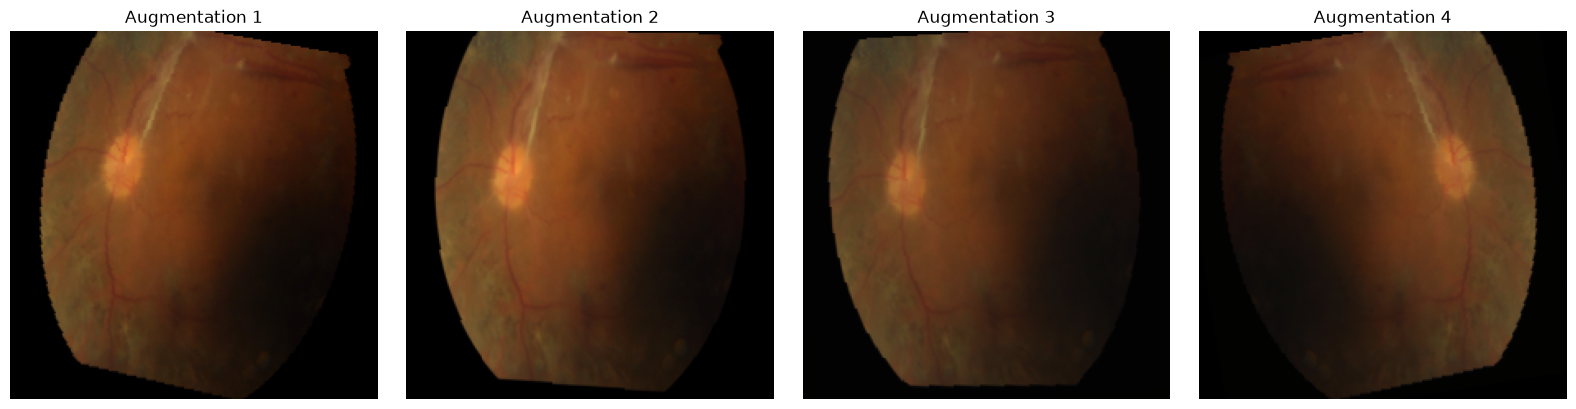

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    transformed = train_transform(image)

    # Undo ImageNet normalization for visualization
    img = transformed.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img * std + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Augmentation {i+1}")

plt.tight_layout()
plt.show()

In [10]:
train_transform = transforms.Compose([
    transforms.Resize(256),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
from PIL import ImageOps


def pad_to_square(image):
    """
    Pad an image to a square while preserving its original aspect ratio.
    Black padding is added around the image.
    """
    width, height = image.size

    max_side = max(width, height)

    pad_left = (max_side - width) // 2
    pad_top = (max_side - height) // 2
    pad_right = max_side - width - pad_left
    pad_bottom = max_side - height - pad_top

    image = ImageOps.expand(
        image,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=(0, 0, 0)
    )

    return image

In [13]:
padded_image = pad_to_square(image)

print("Original size:", image.size)
print("Padded size:", padded_image.size)

Original size: (4288, 2848)
Padded size: (4288, 4288)


In [14]:
train_transform = transforms.Compose([
    transforms.Resize(256),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.Lambda(pad_to_square),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
val_transform = transforms.Compose([
    transforms.Resize(256),

    transforms.Lambda(pad_to_square),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

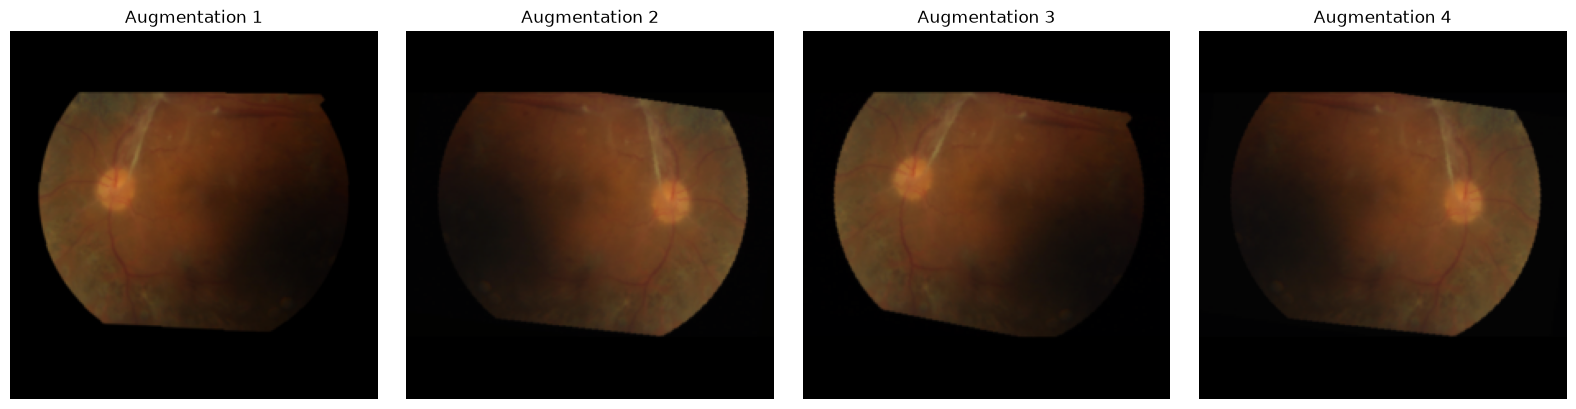

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):

    transformed = train_transform(image)

    # Convert tensor back to image
    img = transformed.permute(1, 2, 0).numpy()

    # Undo ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img * std + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Augmentation {i + 1}")

plt.tight_layout()
plt.show()

In [17]:
train_transform = transforms.Compose([
    # Preserve aspect ratio
    transforms.Resize(512),

    # Conservative augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    # Pad shorter dimension without distortion
    transforms.Lambda(pad_to_square),

    # Final model input
    transforms.Resize((512, 512)),

    # Convert to tensor
    transforms.ToTensor(),

    # ImageNet normalization for pretrained EfficientNet
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [18]:
val_transform = transforms.Compose([
    transforms.Resize(512),

    transforms.Lambda(pad_to_square),

    transforms.Resize((512, 512)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
test_tensor = train_transform(image)

print("Tensor shape:", test_tensor.shape)
print("Tensor dtype:", test_tensor.dtype)

Tensor shape: torch.Size([3, 512, 512])
Tensor dtype: torch.float32


In [20]:
val_tensor = val_transform(image)

print("Validation tensor shape:", val_tensor.shape)
print("Validation tensor dtype:", val_tensor.dtype)

Validation tensor shape: torch.Size([3, 512, 512])
Validation tensor dtype: torch.float32


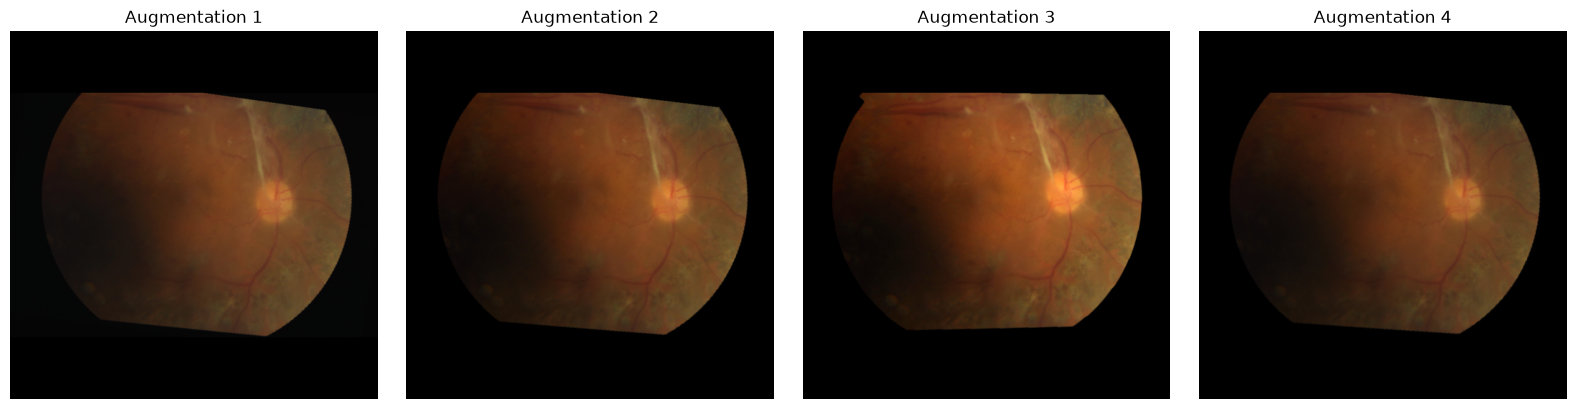

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):

    transformed = train_transform(image)

    # Convert tensor → NumPy
    img = transformed.permute(1, 2, 0).numpy()

    # Undo ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img * std + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Augmentation {i + 1}")

plt.tight_layout()
plt.show()

In [23]:
import sys

PROJECT_DIR = r"D:\diabetic"

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

from src.dataset import DiabeticRetinopathyDataset

print("Dataset class imported successfully")

Dataset class imported successfully


In [24]:
train_dataset = DiabeticRetinopathyDataset(
    dataframe=train_df,
    image_dir=TRAIN_DIR,
    transform=train_transform
)

val_dataset = DiabeticRetinopathyDataset(
    dataframe=val_df,
    image_dir=TRAIN_DIR,
    transform=val_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 2929
Validation dataset: 733


In [25]:
sample_image, sample_label = train_dataset[0]

print("Image tensor shape:", sample_image.shape)
print("Image tensor dtype:", sample_image.dtype)
print("Label:", sample_label)

Image tensor shape: torch.Size([3, 512, 512])
Image tensor dtype: torch.float32
Label: 0


In [26]:
from torch.utils.data import DataLoader

In [27]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2),
        "GB"
    )

CUDA available: False


In [28]:
import torch

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

PyTorch version: 2.14.0+cpu
PyTorch CUDA version: None
CUDA available: False
CUDA device count: 0


In [29]:
import subprocess

result = subprocess.run(
    ["nvidia-smi"],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

Thu Sep 10 01:01:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.08                 Driver Version: 596.08         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   54C    P3              9W /   30W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import sys

PROJECT_DIR = r"D:\diabetic"

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

from src.transforms import (
    train_transform,
    val_transform
)

from src.dataset import DiabeticRetinopathyDataset

print("Transforms and Dataset imported successfully")

Transforms and Dataset imported successfully


In [2]:
train_dataset = DiabeticRetinopathyDataset(
    dataframe=train_df,
    image_dir=TRAIN_DIR,
    transform=train_transform
)

val_dataset = DiabeticRetinopathyDataset(
    dataframe=val_df,
    image_dir=TRAIN_DIR,
    transform=val_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

NameError: name 'train_df' is not defined

In [3]:
import os
import sys
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

PROJECT_DIR = r"D:\diabetic"
DATASET_DIR = r"D:\diabetic\dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "train_images")
TRAIN_CSV = os.path.join(DATASET_DIR, "train.csv")

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

print("Setup complete")

Setup complete


In [4]:
df = pd.read_csv(TRAIN_CSV)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (3662, 2)
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["diagnosis"],
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 2929
Validation samples: 733


In [6]:
from src.dataset import DiabeticRetinopathyDataset
from src.transforms import train_transform, val_transform

print("Dataset and transforms imported successfully")

Dataset and transforms imported successfully


In [7]:
train_dataset = DiabeticRetinopathyDataset(
    dataframe=train_df,
    image_dir=TRAIN_DIR,
    transform=train_transform
)

val_dataset = DiabeticRetinopathyDataset(
    dataframe=val_df,
    image_dir=TRAIN_DIR,
    transform=val_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 2929
Validation dataset: 733


In [8]:
sample_image, sample_label = train_dataset[0]

print("Image tensor shape:", sample_image.shape)
print("Image tensor dtype:", sample_image.dtype)
print("Label:", sample_label)

Image tensor shape: torch.Size([3, 512, 512])
Image tensor dtype: torch.float32
Label: 0


In [9]:
train_dataset = DiabeticRetinopathyDataset(
    dataframe=train_df,
    image_dir=TRAIN_DIR,
    transform=train_transform
)

val_dataset = DiabeticRetinopathyDataset(
    dataframe=val_df,
    image_dir=TRAIN_DIR,
    transform=val_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 2929
Validation dataset: 733


In [10]:
sample_image, sample_label = train_dataset[0]

print("Image tensor shape:", sample_image.shape)
print("Image tensor dtype:", sample_image.dtype)
print("Label:", sample_label)

Image tensor shape: torch.Size([3, 512, 512])
Image tensor dtype: torch.float32
Label: 0


In [11]:
from torch.utils.data import DataLoader
import torch

In [12]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 733
Validation batches: 184


In [13]:
from torch.utils.data import DataLoader
import torch

In [14]:
BATCH_SIZE = 4

print("Batch size:", BATCH_SIZE)

Batch size: 4


In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training DataLoader created")

Training DataLoader created


In [16]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Validation DataLoader created")

Validation DataLoader created


In [17]:
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training images: 2929
Validation images: 733
Training batches: 733
Validation batches: 184


In [18]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("Labels:", labels.tolist())

Batch image shape: torch.Size([4, 3, 512, 512])
Batch labels shape: torch.Size([4])
Image dtype: torch.float32
Label dtype: torch.int64
Labels: [0, 2, 0, 0]


In [19]:
total_images = 0

for images, labels in train_loader:
    total_images += images.size(0)

print("Images loaded through DataLoader:", total_images)

Images loaded through DataLoader: 2929


In [20]:
print("PyTorch:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / (1024**3),
            2
        ),
        "GB"
    )

PyTorch: 2.14.0+cu132
CUDA version: 13.2
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU memory: 6.0 GB


In [21]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [22]:
images = images.to(device)
labels = labels.to(device)

print("Images device:", images.device)
print("Labels device:", labels.device)

Images device: cuda:0
Labels device: cuda:0


In [23]:
from src.model import create_model

In [24]:
model = create_model(num_classes=5, pretrained=True)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


In [25]:
model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [26]:
model.eval()

with torch.no_grad():

    images, labels = next(iter(train_loader))

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([4, 3, 512, 512])
Output shape: torch.Size([4, 5])
Labels shape: torch.Size([4])


In [27]:
predicted_classes = outputs.argmax(dim=1)

print("Actual labels:   ", labels.cpu().tolist())
print("Predicted labels:", predicted_classes.cpu().tolist())

Actual labels:    [3, 0, 4, 2]
Predicted labels: [1, 1, 1, 1]


In [28]:
import torch
import torch.nn as nn

class_weights = torch.tensor(
    [0.40567867, 1.97905405, 0.73316646, 3.8038961, 2.48220339],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Class weights:", class_weights)
print("Loss function:", criterion)

Class weights: tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822], device='cuda:0')
Loss function: CrossEntropyLoss()


In [29]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [30]:
NUM_EPOCHS = 10

print("Epochs:", NUM_EPOCHS)

Epochs: 10
